<a href="https://colab.research.google.com/github/romeuqf/Alura/blob/main/Introdu%C3%A7%C3%A3o_a_Machine_Learning_Classifica%C3%A7%C3%A3o_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
uri = "https://gist.githubusercontent.com/guilhermesilveira/1b7d5475863c15f484ac495bd70975cf/raw/16aff7a0aee67e7c100a2a48b676a2d2d142f646/projects.csv"
mapa= {'unfinished':'inacabado',
       'expected_hours':'horas_esperadas',
       'price':'preco'}
base = pd.read_csv(uri)
base = base.rename(columns=mapa)
base.head()

,inacabado,horas_esperadas,preco
0,1,26,192
1,1,88,9015
2,1,89,2577
3,1,42,275
4,1,39,170


In [ ]:
trocar = {0:1,
          1:0}
base['finalizado'] = base.inacabado.map(trocar)
base.head()

,inacabado,horas_esperadas,preco,finalizado
0,1,26,192,0
1,1,88,9015,0
2,1,89,2577,0
3,1,42,275,0
4,1,39,170,0


In [ ]:
base.tail()

,inacabado,horas_esperadas,preco,finalizado
2152,0,80,7518,1
2153,1,52,1332,0
2154,0,40,473,1
2155,0,75,5324,1
2156,1,37,377,0


<Axes: xlabel='horas_esperadas', ylabel='preco'>

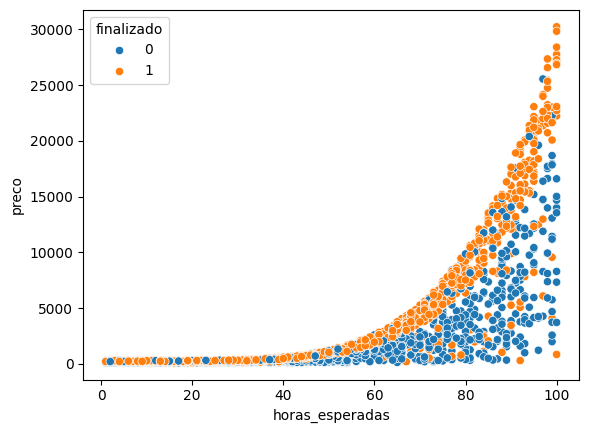

In [ ]:
import seaborn as sns
sns.scatterplot(x='horas_esperadas',y='preco',hue='finalizado',data=base)

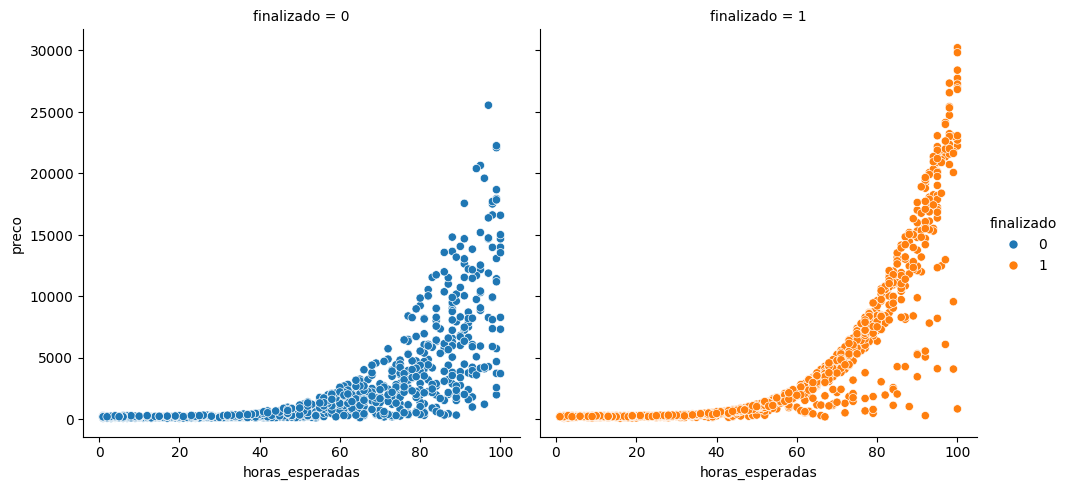

In [ ]:
sns.relplot(x='horas_esperadas',y='preco',col='finalizado',hue='finalizado',data=base)

In [ ]:
x = base[['horas_esperadas','preco']]
y = base['finalizado']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x,y,random_state=SEED, test_size=0.25,stratify=y)
print(treino_x.shape)
print(teste_x.shape)
print('Treinaremos com %d e testaremos com %d elementos' %(len(treino_x),len(teste_x)))
modelo = LinearSVC()
modelo.fit(treino_x,treino_y)
previsoes = modelo.predict(teste_x)
acuracio = accuracy_score(teste_y,previsoes)*100
print('A acuracia foi %.2f%%' %acuracio)

(1617, 2)
(540, 2)
Treinaremos com 1617 e testaremos com 540 elementos


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


A acuracia foi 53.70%


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
import numpy as np

previsoes_base = np.ones(540)
acuracio_romeu = accuracy_score(teste_y,previsoes_base)*100
print('A acuracia do algoritmo de previsao de base (baseline) foi %.2f%%' %acuracio_romeu)

A acuracia do algoritmo de previsao de base (baseline) foi 52.59%


<Axes: xlabel='horas_esperadas', ylabel='preco'>

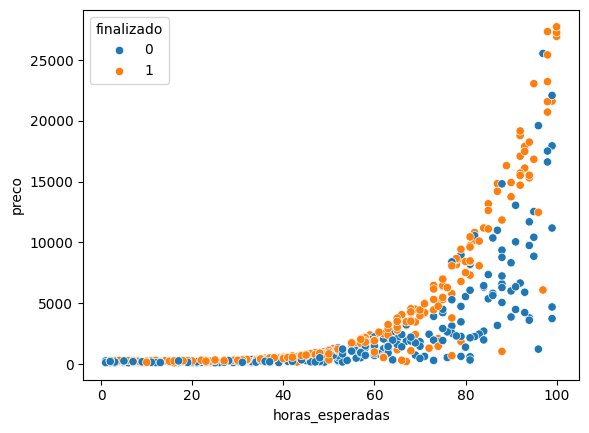

In [ ]:
sns.scatterplot(x='horas_esperadas',y='preco',hue=teste_y,data=teste_x)

In [ ]:
teste_x_min = teste_x.horas_esperadas.min()
teste_x_max = teste_x.horas_esperadas.max()
teste_y_min = teste_x.preco.min()
teste_y_max = teste_x.preco.max()
print(teste_x_min, teste_x_max, teste_y_min, teste_y_max)

1 100 101 27738


In [ ]:
pixels = 100
eixo_x = np.arange(teste_x_min, teste_x_max, (teste_x_max - teste_x_min) / pixels)
eixo_y = np.arange(teste_y_min, teste_y_max, (teste_y_max - teste_y_min) / pixels)

In [ ]:
xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]
pontos

array([[1.000000e+00, 1.010000e+02],
       [1.990000e+00, 1.010000e+02],
       [2.980000e+00, 1.010000e+02],
       ...,
       [9.703000e+01, 2.746163e+04],
       [9.802000e+01, 2.746163e+04],
       [9.901000e+01, 2.746163e+04]])

In [ ]:
Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


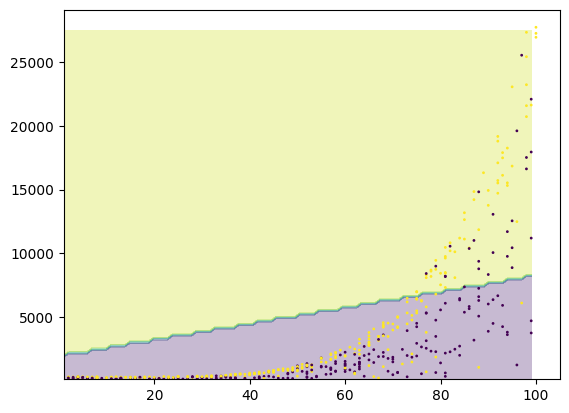

In [ ]:
import matplotlib.pyplot as plt
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(x='horas_esperadas',y='preco',c=teste_y,data=teste_x,s=1)

# DECISION BOUNDARY

In [ ]:
from sklearn.svm import SVC

SEED = 5
np.random.seed(SEED)
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size = 0.25,
                                                         stratify = y)
print("Treinaremos com %d elementos e testaremos com %d elementos" % (len(treino_x), len(teste_x)))

modelo = SVC(gamma='auto')

Treinaremos com 1617 elementos e testaremos com 540 elementos


In [ ]:
modelo.fit(treino_x,treino_y)
previsoes = modelo.predict(teste_x)
acuracia = accuracy_score(teste_y, previsoes) * 100
print("A acurácia foi %.2f%%" % acuracia)

A acurácia foi 59.07%


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


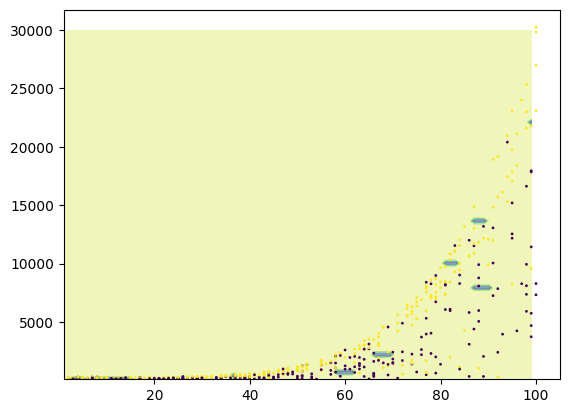

In [ ]:
teste_x_min = teste_x.horas_esperadas.min()
teste_x_max = teste_x.horas_esperadas.max()
teste_y_min = teste_x.preco.min()
teste_y_max = teste_x.preco.max()
pixels = 100
eixo_x = np.arange(teste_x_min, teste_x_max, (teste_x_max - teste_x_min) / pixels)
eixo_y = np.arange(teste_y_min, teste_y_max, (teste_y_max - teste_y_min) / pixels)
xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]
Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)
import matplotlib.pyplot as plt
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(x='horas_esperadas',y='preco',c=teste_y,data=teste_x,s=1)

# DECISION BOUNDARY

In [ ]:
#refazer a escala de X e Y para o mesmo número
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
SEED = 20
np.random.seed(SEED)

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x,y, test_size=0.25,stratify=y)
print('Treinaremos com %d e testaremos com %d elementos' %(len(treino_x),len(teste_x)))

scaler = StandardScaler()
scaler.fit(raw_treino_x)
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = SVC()
modelo.fit(treino_x,treino_y)
previsoes = modelo.predict(teste_x)
acuracio = accuracy_score(teste_y,previsoes)*100
print('A acuracia foi %.2f%%' %acuracio)


(1617, 2)
(540, 2)
Treinaremos com 1617 e testaremos com 540 elementos
A acuracia foi 70.37%


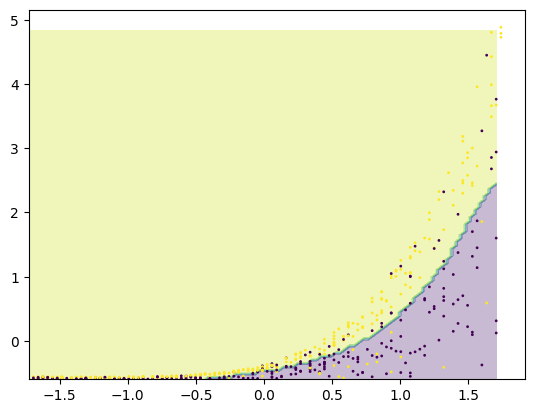

In [ ]:
data_x = teste_x[:,0]
data_y = teste_x[:,1]
data_z = teste_y

teste_x_min = data_x.min()
teste_x_max = data_x.max()
teste_y_min = data_y.min()
teste_y_max = data_y.max()
pixels = 100
eixo_x = np.arange(teste_x_min, teste_x_max, (teste_x_max - teste_x_min) / pixels)
eixo_y = np.arange(teste_y_min, teste_y_max, (teste_y_max - teste_y_min) / pixels)
xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]
Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)
import matplotlib.pyplot as plt
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(data_x,data_y,c=data_z,s=1)

# DECISION BOUNDARY